# P655: Product Recommendation System

##Objective:
The main objective of the P655 project is to build an intelligent system that analyzes user data and recommends products that
the user is likely to purchase or find useful.

## Importing Libraries

We import the necessary Python libraries for data analysis and visualization.

- pandas → for data manipulation
- numpy → for numerical operations
- matplotlib & seaborn → for visualization

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# Display settings
plt.style.use('default')

## Loading the Dataset

We load the dataset containing user-product interactions.

Each row represents:
- A user
- A product
- The rating given by the user

In [2]:
# Upload file in Colab OR mount Google Drive
df = pd.read_csv('rating_short.csv')
print("Dataset loaded successfully")

# Preview dataset
df.head()

Dataset loaded successfully


,userid,productid,rating,date
0,A1Z3YJF1S8Z1M3,B000M9ISQ2,5.0,1199750400
1,ALDXDYEGKB27G,B002L6HE9G,4.0,1331337600
2,A15LOGO6NBSI6B,B007MXGG5Q,5.0,1358640000
3,A23LX12CA3G4FG,B008HOEDYU,1.0,1385337600
4,A3TV7QFYXAG130,B0069R7TAM,5.0,1402963200


## Basic Dataset Information

We examine:
- Number of rows and columns
- Data types
- Summary statistics

This helps us understand the structure and scale of the dataset.

In [3]:
# Dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78245 entries, 0 to 78244
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   userid     78245 non-null  object 
 1   productid  78245 non-null  object 
 2   rating     78245 non-null  float64
 3   date       78245 non-null  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 2.4+ MB


## Data Cleaning

We remove unnecessary columns and duplicate records.

- The 'date' column is not useful for recommendation systems.
- Duplicate entries can distort analysis.

In [4]:
# Drop unnecessary column
if 'date' in df.columns:
    df = df.drop('date', axis=1)

# Remove duplicates
df = df.drop_duplicates()

# Check again
df.head()

,userid,productid,rating
0,A1Z3YJF1S8Z1M3,B000M9ISQ2,5.0
1,ALDXDYEGKB27G,B002L6HE9G,4.0
2,A15LOGO6NBSI6B,B007MXGG5Q,5.0
3,A23LX12CA3G4FG,B008HOEDYU,1.0
4,A3TV7QFYXAG130,B0069R7TAM,5.0


In [5]:
#Statistical summary
df.describe()


,rating
count,78245.000000
mean,4.006454
std,1.385342
min,1.000000
25%,3.000000
50%,5.000000
75%,5.000000
max,5.000000


## Key Insight: Ratings are highly skewed
Data shows:

median = 5 and
mean ≈ 4

This means:

Most users gave high ratings

Dataset is positively biased

Quartiles:

25% = 3

50% = 5

75% = 5

At least 50% of all ratings are 5 stars

## Missing Values Check

We check if there are any missing values in the dataset.

Handling missing values is important to ensure data quality.

In [6]:
# Check missing values
df.isnull().sum()

,0
userid,0
productid,0
rating,0



**There are no missing values in the dataset, which means the data is clean and ready for analysis.**

## Dataset Statistics

We calculate:
- Total number of ratings
- Total unique users
- Total unique products

This helps us understand dataset scale.

In [7]:
print("Total Ratings:", len(df['rating']))
print("Total Unique Users:", df['userid'].nunique())
print("Total Unique Products:", df['productid'].nunique())

Total Ratings: 78245
Total Unique Users: 76430
Total Unique Products: 40228


**The dataset contains a large number of users and products, indicating a real-world recommendation scenario.**

## Rating Distribution

* We analyze how users rate products.

* This helps identify bias in ratings.

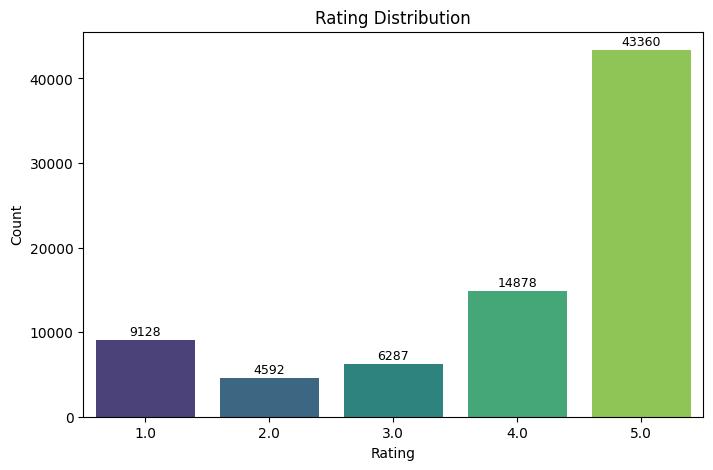

In [8]:
plt.figure(figsize=(8,5))

ax = sns.countplot(x='rating', data=df, palette='viridis')

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

# Add values on top
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height + 500, int(height),
            ha='center', fontsize=9)

plt.show()


**Most ratings are concentrated around higher values (4–5), indicating a positive bias in user feedback.**

## User Activity Analysis

We analyze how active users are based on the number of ratings they give.

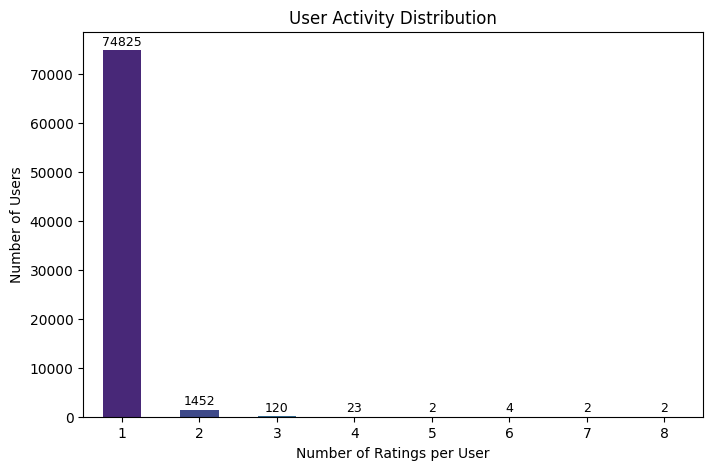

In [9]:
# Count number of ratings per user
user_counts = df['userid'].value_counts()

# Count frequency of those counts
user_activity = user_counts.value_counts().sort_index()

plt.figure(figsize=(8,5))
colors = sns.color_palette("viridis", len(user_activity))
ax = user_activity.plot(kind='bar', color=colors)

plt.title("User Activity Distribution")
plt.xlabel("Number of Ratings per User")
plt.ylabel("Number of Users")

# Add values on top
for i, v in enumerate(user_activity):
    ax.text(i, v + 1000, str(v), ha='center', fontsize=9)

plt.xticks(rotation=0)
plt.show()

INSIGHTS:

Ratings per user  Number of users

1                74,825 -rated only one product  

2                1,452 -rated 2 products   

3                120 -rated 3 products

4                23  -rated 4 products              

Main insight:  Dataset is extremely sparse

Out of 78,245 total ratings, almost 95% users rated only one product.

Most users interacted only once and never returned.


**Most users give very few ratings, while a small number of users are highly active.
This leads to uneven data distribution.**

## Product Popularity Analysis

We analyze how frequently products are rated.

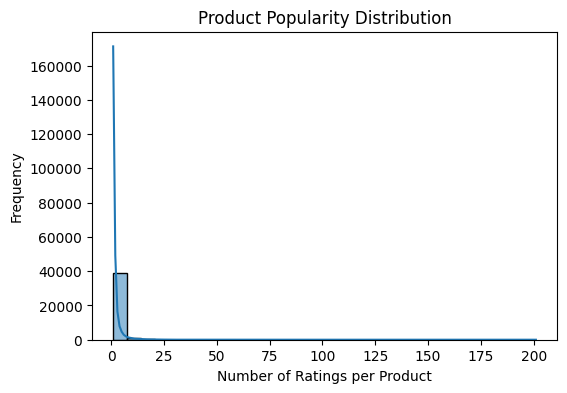

In [10]:
product_counts = df['productid'].value_counts()

plt.figure(figsize=(6,4))
sns.histplot(product_counts, bins=30, kde=True)
plt.title("Product Popularity Distribution")
plt.xlabel("Number of Ratings per Product")
plt.ylabel("Frequency")
plt.show()

Observation:

A very tall spike near 0–5 ratings

Then a long flat tail up to ~200 ratings


**A few products receive a large number of ratings, while most products have very few ratings.
This is known as the long-tail distribution(Right Skewed).**

## Top 10 Most Rated Products

Identifying the most popular products based on the number of ratings received.

- We count how many times each product has been rated.
- Then we select the top 10 most frequently rated products.
- This helps us understand which products dominate user interactions.

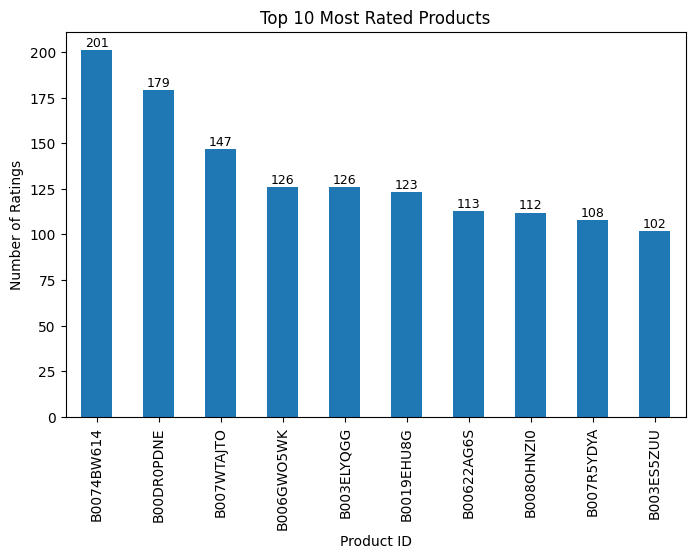

In [11]:
top_products = df['productid'].value_counts().head(10)

plt.figure(figsize=(8,5))
ax = top_products.plot(kind='bar')

plt.title("Top 10 Most Rated Products")
plt.xlabel("Product ID")
plt.ylabel("Number of Ratings")

# Add values on top of bars
for i, v in enumerate(top_products):
    ax.text(i, v + 2, str(v), ha='center', fontsize=9)

plt.show()

## Top 10 Most Active Users

Identifying the most active users based on the number of ratings they have given.

We count the number of ratings per user.
Then we select the top 10 users with the highest activity.
This helps us understand user engagement patterns.

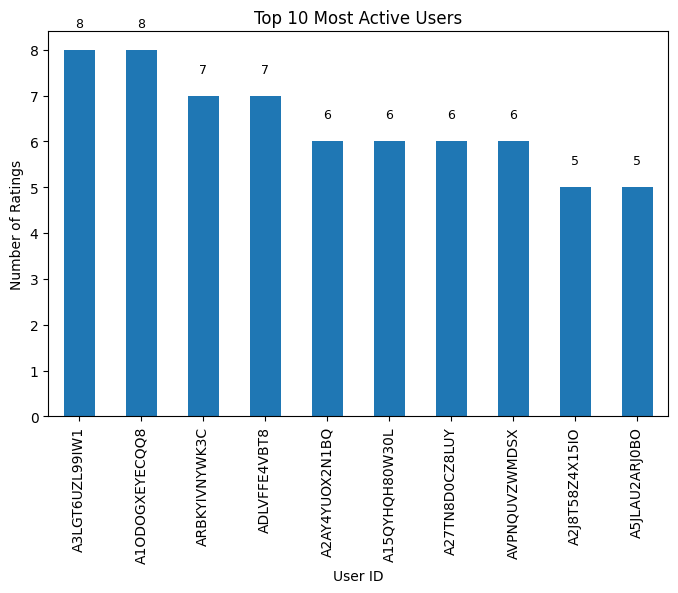

In [12]:
top_users = df['userid'].value_counts().head(10)

plt.figure(figsize=(8,5))
ax = top_users.plot(kind='bar')

plt.title("Top 10 Most Active Users")
plt.xlabel("User ID")
plt.ylabel("Number of Ratings")

# Add values on top of bars
for i, v in enumerate(top_users):
    ax.text(i, v + 0.5, str(v), ha='center', fontsize=9)

plt.show()

## Data Filtering

To improve model performance and reduce sparsity:
- Remove users with very few ratings
- Remove products with very few ratings

In [13]:
# Keep users with at least 2 ratings
active_users = user_counts[user_counts >= 2].index
df_filtered = df[df['userid'].isin(active_users)]

# Keep products with at least 2 ratings
product_counts = df_filtered['productid'].value_counts()
popular_products = product_counts[product_counts >= 2].index
df_filtered = df_filtered[df_filtered['productid'].isin(popular_products)]

print("Filtered dataset shape:", df_filtered.shape)

Filtered dataset shape: (583, 3)


**Filtering reduces noise and improves recommendation quality by focusing on meaningful interactions.**

# TOP 10 USERS

In [14]:
user_activity = df_filtered.groupby('userid')['rating'].count()
top_users = user_activity.sort_values(ascending=False).head(10)
print(top_users)

userid
A2J8T58Z4X15IO    3
AZQFM7JM1KUO9     2
AYPCLLUC7V5P7     2
AN8JC5CWXJV0Z     2
A17UNMURMLX0ZE    2
AQBER2BLR3XZS     2
A196WWEMCULYKW    2
AOJYHMZ5S8B5K     2
APZZK3DRG7J8K     2
AQ8ATZLT4GJVZ     2
Name: rating, dtype: int64


**A small number of users are highly active, while most users give very few ratings.
This shows uneven user participation.**


## TOP 10 PRODUCTS

In [15]:
product_popularity = df_filtered.groupby('productid')['rating'].count()
top_products = product_popularity.sort_values(ascending=False).head(10)
print(top_products)

productid
B003ES5ZUU    10
B007WTAJTO     7
B003ELYQGG     5
B00AWKC0JM     5
B005FYNSPK     5
B002WE6D44     5
B00DR0PDNE     5
B004T9RR6I     4
B0049YQVHE     4
B006W8U2MU     4
Name: rating, dtype: int64


**Only a few products receive most of the ratings, while many products have very few.
This shows a popularity imbalance in the dataset.**

## User-Item Matrix Construction

###  What this cell does:
This step converts the transactional dataset into a **User-Item Matrix** using a pivot table:
- Rows → Users (`user_id`)
- Columns → Items (`productid`)
- Values → Ratings

###  Why this is important:
This matrix is the **foundation of collaborative filtering**:
- Helps represent user behavior numerically
- Enables similarity computation and clustering



In [16]:
user_item_matrix = df_filtered.pivot_table(
    index='userid',
    columns='productid',
    values='rating'
)

print(user_item_matrix.shape)

(515, 246)



**The user-item matrix is sparse, meaning most entries are missing.
This is typical in recommendation systems.**

## User-Item Matrix Heatmap


- Visualizes a subset of the user-item matrix using a heatmap
- Colors represent rating intensity
- To visually understand how sparse the data is
- To identify interaction patterns

###  Graph Insight:
- Most cells are empty (no color) → very few interactions
- Only a few colored spots → users interact with limited items



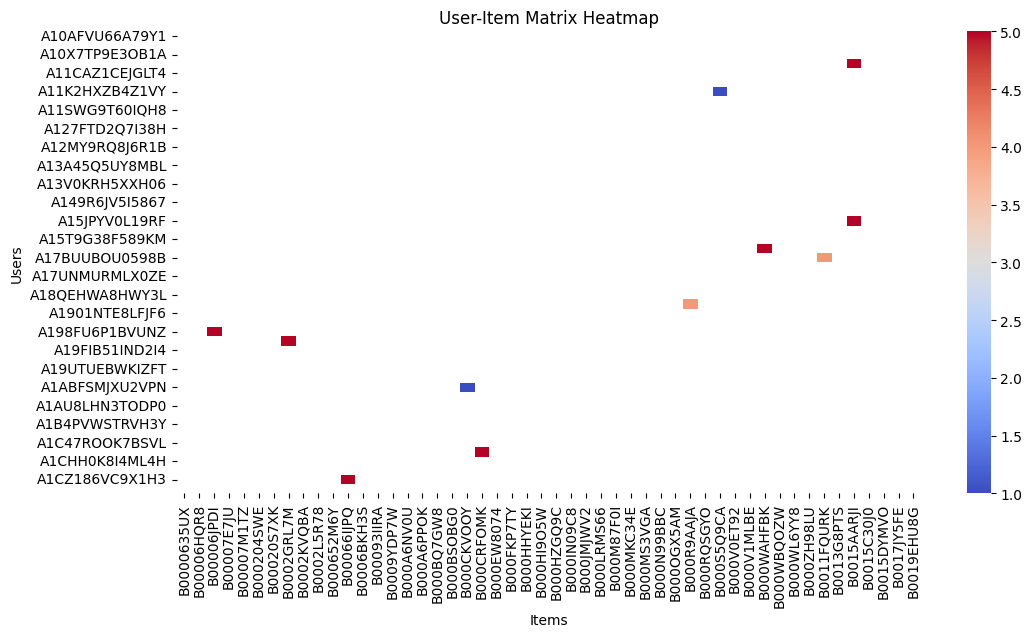

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sample_matrix = user_item_matrix.iloc[:50, :50]
sns.heatmap(sample_matrix, cmap='coolwarm')
plt.title("User-Item Matrix Heatmap")
plt.xlabel("Items")
plt.ylabel("Users")
plt.show()

###  Interpretation:
- Confirms **extreme sparsity**
- Users have interacted with only a small subset of products

###  Conclusion:
This sparsity justifies the use of:
- Collaborative Filtering
- Dimensionality Reduction (SVD)

## Sparsity Calculation




Calculates how much of the matrix is empty using:

Sparsity = 1 - (Non-zero entries / Total entries)

### Result:
- Sparsity ≈ **0.9953 (99.53%)**

### Key Insight:
- Extremely high sparsity → almost all values are missing

###  Interpretation:
- Traditional ML models struggle with sparse data
- Memory-based recommendation becomes inefficient





In [18]:
sparsity = 1 - (user_item_matrix.count().sum() / (user_item_matrix.shape[0] * user_item_matrix.shape[1]))

print("Sparsity:", sparsity)

Sparsity: 0.9953982161180835



**High sparsity confirms that most user-product interactions are missing, making collaborative filtering a suitable approach.**

##  Sparsity Pattern (Filled vs Empty)

- Converts matrix into binary:
  - 1 → interaction exists
  - 0 → no interaction
- Displays heatmap

###  Graph Insight:
- Dark regions dominate → empty values
- White dots → very few interactions

###  Interpretation:
- Confirms dataset is **highly sparse and randomly distributed**
- No dense clusters visible at raw level

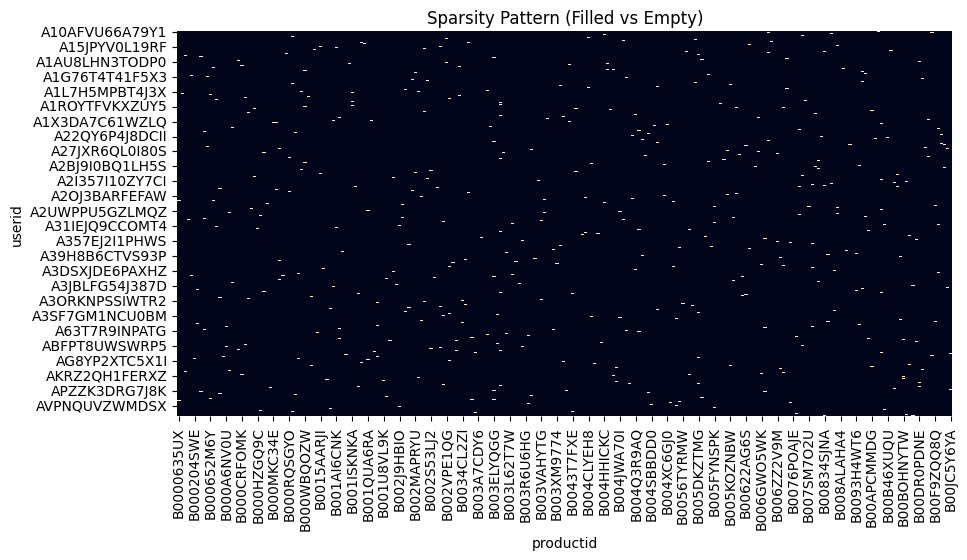

In [59]:
plt.figure(figsize=(10,5))
sns.heatmap(user_item_matrix > 0, cbar=False)
plt.title("Sparsity Pattern (Filled vs Empty)")
plt.show()

## 🔹 Data Normalization

1. Subtracts mean rating of each user (centering)
2. Fills missing values with 0

###  Why this is important:
- Removes user bias (some users rate higher than others)
- Makes similarity calculations more meaningful



In [19]:
# Normalize ratings instead of filling with 0
user_item_matrix_centered = user_item_matrix.sub(user_item_matrix.mean(axis=1), axis=0)

# Fill remaining NaNs with 0 AFTER centering
user_item_matrix_filled = user_item_matrix_centered.fillna(0)

# MODEL BUILDING




##  Label Encoding

- Converts:
  - user_id → numerical
  - product_id → numerical

### Why this is needed:
- Machine learning models require numerical input
- Ensures consistent indexing


In [20]:
from sklearn.preprocessing import LabelEncoder
user_encoder_full = LabelEncoder()
item_encoder_full = LabelEncoder()

df_filtered['userId_enc'] = user_encoder_full.fit_transform(df_filtered['userid'])
df_filtered['productId_enc'] = item_encoder_full.fit_transform(df_filtered['productid'])

##  Sparse Matrix (CSR Format)

- Converts data into a sparse matrix using COO → CSR format

###  Why this is important:
- Efficient memory usage
- Faster computation



In [21]:
from scipy.sparse import coo_matrix
full_sparse = coo_matrix(
    (df_filtered['rating'],
     (df_filtered['userId_enc'], df_filtered['productId_enc']))
).tocsr()


##  Dimensionality Reduction using SVD

- Reduces high-dimensional data into 50 latent features

###  Output:
- Reduced shape: (515, 50)
- Explained variance: ~37%

###  Interpretation:
- Captures hidden patterns in user behavior
- Reduces noise and sparsity




In [22]:
from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(n_components=50, random_state=42)
reduced_data = svd.fit_transform(full_sparse)
print("Reduced shape:", reduced_data.shape)
print("Explained Variance Ratio:", svd.explained_variance_ratio_.sum())

Reduced shape: (515, 50)
Explained Variance Ratio: 0.3760328385272937


##  Feature Scaling


- Standardizes features using StandardScaler

###  Why this is important:
- KMeans is distance-based → requires scaling



In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(reduced_data)

## Kmeans

In [24]:
from sklearn.cluster import KMeans
inertia = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)



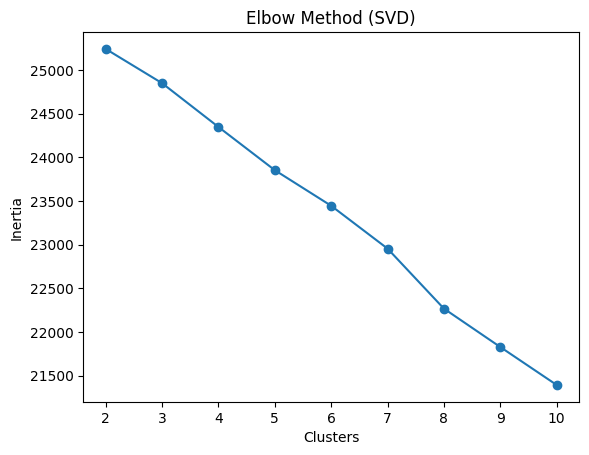

In [25]:
plt.plot(K, inertia, marker='o')
plt.title("Elbow Method (SVD)")
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.show()

**K = 7 is selected as the optimal number of clusters, balancing model complexity and performance.**

## K-Means Clustering

K-Means clustering is applied to group users into 7 clusters based on their behavior.

The number of clusters (K=7) was chosen using the Elbow Method.
The algorithm assigns each user to the nearest cluster centroid.
Users within the same cluster exhibit similar rating patterns.
This helps in identifying user segments for personalized recommendations.

In [26]:
kmeans = KMeans(n_clusters=7, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)

## 🔹 KMeans Cluster Visualization


- Reduces data to 2D using PCA
- Plots clusters and centroids

###  Graph Insight:
- One dominant cluster (large group)
- Few small clusters → niche users
- Some overlap present


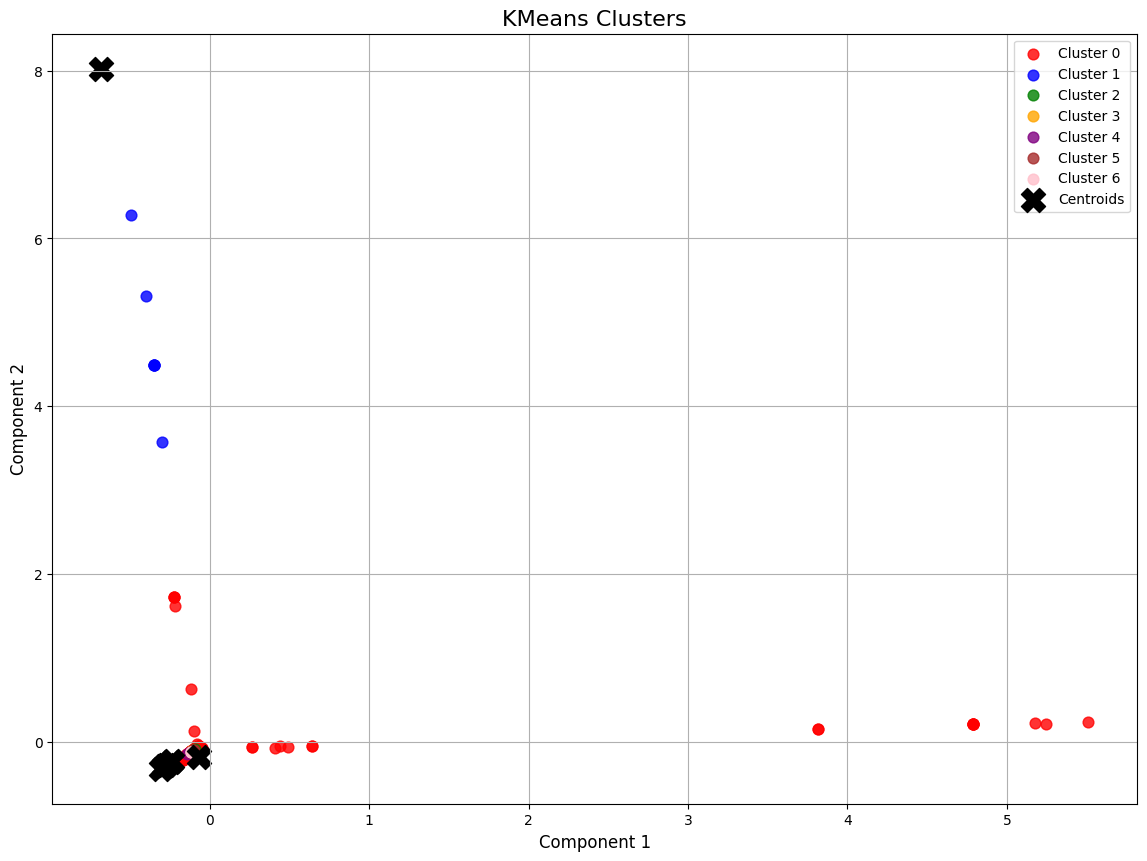

In [27]:
from sklearn.decomposition import PCA

# PCA to 2D
pca = PCA(n_components=2)
reduced_2d = pca.fit_transform(reduced_data)

# Centroids
centers_2d = pca.transform(kmeans.cluster_centers_)

# Strong, distinct colors
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown','pink']

plt.figure(figsize=(14,10))

# Plot each cluster separately
for i in range(7):
    plt.scatter(
        reduced_2d[kmeans_labels == i, 0],
        reduced_2d[kmeans_labels == i, 1],
        color=colors[i],
        label=f"Cluster {i}",
        s=60,          # bigger points
        alpha=0.8      # slightly transparent
    )

# Plot centroids
plt.scatter(
    centers_2d[:, 0],
    centers_2d[:, 1],
    c='black',
    s=300,
    marker='X',
    label='Centroids'
)

plt.title("KMeans Clusters", fontsize=16)
plt.xlabel("Component 1", fontsize=12)
plt.ylabel("Component 2", fontsize=12)

plt.legend(fontsize=10)
plt.grid(True)

plt.show()



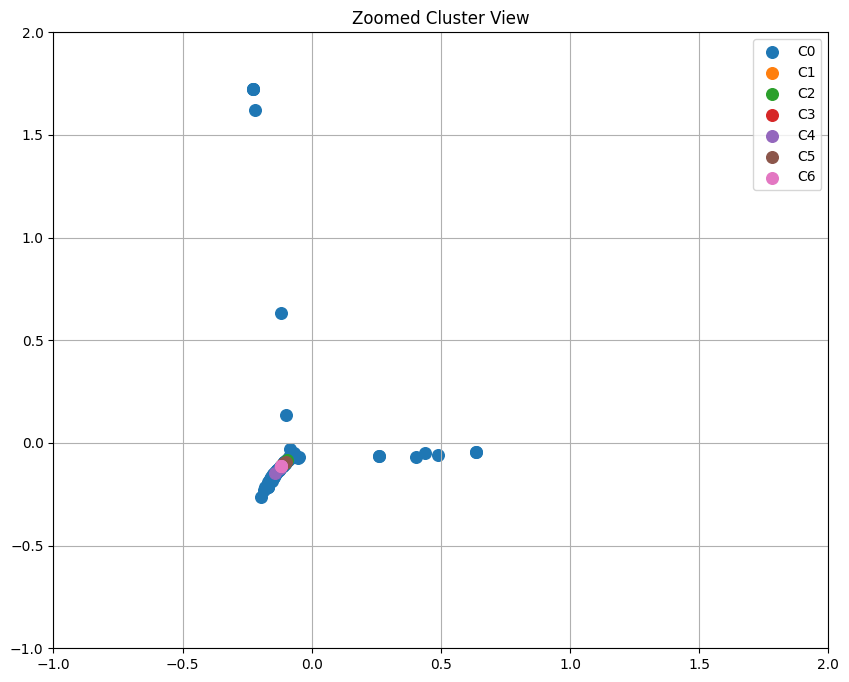

In [28]:
plt.figure(figsize=(10,8))

for i in range(7):
    plt.scatter(
        reduced_2d[kmeans_labels == i, 0],
        reduced_2d[kmeans_labels == i, 1],
        label=f"C{i}",
        s=70
    )

plt.xlim(-1, 2)   # zoom area
plt.ylim(-1, 2)

plt.legend()
plt.title("Zoomed Cluster View")
plt.grid(True)
plt.show()

In [64]:
# Count users in each KMeans cluster
import pandas as pd

kmeans_cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()

print("KMeans Cluster Distribution:")
print(kmeans_cluster_counts)

KMeans Cluster Distribution:
0    494
1      7
2      2
3      3
4      3
5      3
6      3
Name: count, dtype: int64


In [29]:
from sklearn.metrics import silhouette_score,davies_bouldin_score,calinski_harabasz_score
kmeans_score = silhouette_score(scaled_data, kmeans_labels)
print("KMeans Score:", kmeans_score)
db_score = davies_bouldin_score(scaled_data,kmeans_labels)
print("Davies-Bouldin Scores:", db_score)
ch_score = calinski_harabasz_score(scaled_data,kmeans_labels)
print("Calinski-Harabasz Scores:", ch_score)

KMeans Score: 0.3518014118232318
Davies-Bouldin Scores: 0.590269120242629
Calinski-Harabasz Scores: 10.310681995179428


### Cluster Evaluation Metrics

Three metrics are used:

1. Silhouette Score → Measures cluster separation
   - Range: [-1, 1]
   - Obtained: ~0.35 (moderate)

2. Davies-Bouldin Score → Lower is better
   - Obtained: ~0.59 (good)

3. Calinski-Harabasz Score → Higher is better
   - Obtained: ~10.310

## Hierarchical Clustering

Hierarchical clustering is applied to group users based on similarity.

It follows a bottom-up approach where each user starts as a separate cluster.
Clusters are merged step by step based on similarity.
Due to computational complexity, clustering is performed on a subset of data.
This method provides a structural view of user relationships and is useful for comparison with K-Means.

In [30]:
from sklearn.cluster import AgglomerativeClustering
hierarchical = AgglomerativeClustering(n_clusters=7)
hierarchical_labels = hierarchical.fit_predict(reduced_data[:2000])


- Groups users using bottom-up approach
- Similar structure to KMeans
- Slightly better grouping of small clusters



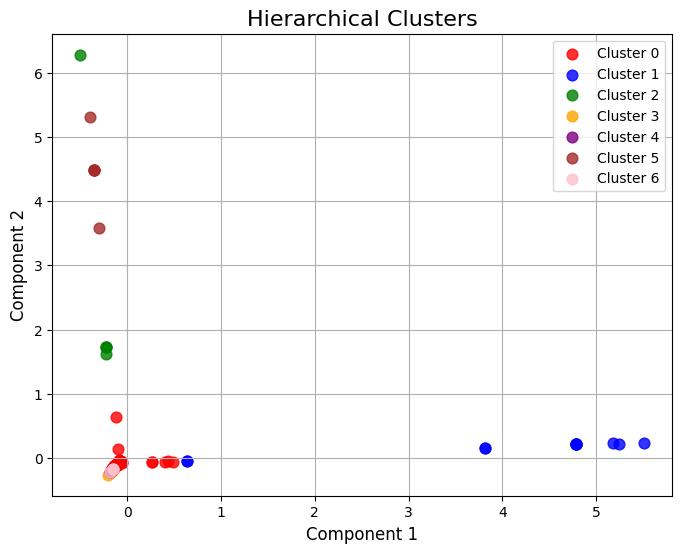

In [31]:
# Use same PCA (or recompute)
pca = PCA(n_components=2)
subset_data = reduced_data[:2000]
subset_2d = pca.fit_transform(subset_data)

# Strong distinct colors
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown','pink']

plt.figure(figsize=(8,6))

# Plot clusters
for i in range(7):
    plt.scatter(
        subset_2d[hierarchical_labels == i, 0],
        subset_2d[hierarchical_labels == i, 1],
        color=colors[i],
        label=f"Cluster {i}",
        s=60,
        alpha=0.8
    )

plt.title("Hierarchical Clusters", fontsize=16)
plt.xlabel("Component 1", fontsize=12)
plt.ylabel("Component 2", fontsize=12)

plt.legend(fontsize=10)
plt.grid(True)

plt.show()

The hierarchical clustering visualization shows a similar pattern to K-Means:

A large cluster represents the majority of users with similar behavior.
Smaller clusters represent users with distinct or niche preferences.
Hierarchical clustering provides slightly better structural grouping, capturing subtle differences between users.

However, overlap is still observed due to similarity in user behavior and dimensionality reduction.

In [66]:
# Count users in each Hierarchical cluster
hier_cluster_counts = pd.Series(hierarchical_labels).value_counts().sort_index()

print("Hierarchical Cluster Distribution:")
print(hier_cluster_counts)

Hierarchical Cluster Distribution:
0    478
1     12
2      5
3      5
4      5
5      6
6      4
Name: count, dtype: int64


In [32]:
from sklearn.metrics import silhouette_score,davies_bouldin_score,calinski_harabasz_score
kmeans_score = silhouette_score(scaled_data,hierarchical_labels)
print("silhoutte Score for hierarchical :", kmeans_score)
db_score = davies_bouldin_score(scaled_data,hierarchical_labels)
print("Davies-Bouldin Scores for hierarchical:", db_score)
ch_score = calinski_harabasz_score(scaled_data,hierarchical_labels)
print("Calinski-Harabasz Scores for hierarchical:", ch_score)

silhoutte Score for hierarchical : 0.33637086203496935
Davies-Bouldin Scores for hierarchical: 0.9486969001548929
Calinski-Harabasz Scores for hierarchical: 10.825143362842368


## DBSCAN CLUSTERING

In [33]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

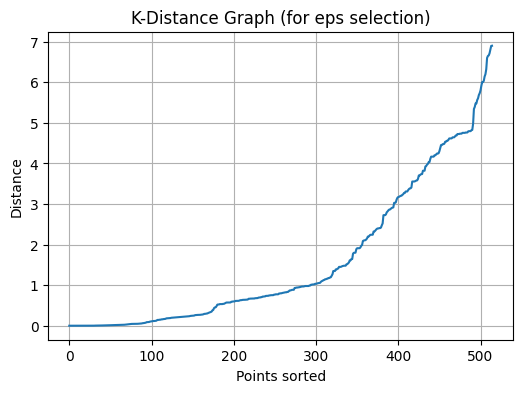

In [34]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(reduced_data)

distances, indices = neighbors_fit.kneighbors(reduced_data)

# Sort distances
distances = np.sort(distances[:, -1])

plt.figure(figsize=(6,4))
plt.plot(distances)
plt.title("K-Distance Graph (for eps selection)")
plt.xlabel("Points sorted")
plt.ylabel("Distance")
plt.grid()
plt.show()

In [35]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

eps_values = np.arange(0.5, 2.0, 0.1)
best_eps = None
best_score = -1

for eps in eps_values:
    labels = DBSCAN(eps=eps, min_samples=5).fit_predict(scaled_data)

    # Remove noise
    mask = labels != -1

    if len(set(labels[mask])) > 1:
        score = silhouette_score(scaled_data[mask], labels[mask])

        if score > best_score:
            best_score = score
            best_eps = eps

print("Best eps:", best_eps)

Best eps: 0.5


In [36]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(scaled_data)

# Count clusters
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("Clusters:", n_clusters)
print("Noise points:", n_noise)

Clusters: 2
Noise points: 387


In [67]:
# Count users in DBSCAN clusters
dbscan_cluster_counts = pd.Series(labels).value_counts().sort_index()

print("DBSCAN Cluster Distribution:")
print(dbscan_cluster_counts)

DBSCAN Cluster Distribution:
-1    387
 0    123
 1      5
Name: count, dtype: int64


In [37]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Remove noise points
mask = labels != -1

if len(set(labels[mask])) > 1:
    sil_score = silhouette_score(reduced_data[mask], labels[mask])
    db_score = davies_bouldin_score(reduced_data[mask], labels[mask])
    ch_score = calinski_harabasz_score(reduced_data[mask], labels[mask])

    print("Silhouette Score:", sil_score)
    print("Davies-Bouldin Score:", db_score)
    print("Calinski-Harabasz Score:", ch_score)
else:
    print("DBSCAN did not form meaningful clusters")

Silhouette Score: 0.9803096985099633
Davies-Bouldin Score: 0.012915839882164173
Calinski-Harabasz Score: 14463.472701636334


In [68]:
# Total points
total_points = len(labels)

# Noise points (label = -1)
noise_points = np.sum(labels == -1)

# Ratio
noise_ratio = noise_points / total_points

print("Total Points:", total_points)
print("Noise Points:", noise_points)


Total Points: 515
Noise Points: 387


In [39]:
noise_ratio_percent = (noise_points / total_points) * 100

print(f"Noise Ratio: {noise_ratio:.3f}")
print(f"Noise Percentage: {noise_ratio_percent:.2f}%")

Noise Ratio: 0.751
Noise Percentage: 75.15%


## USING K MEANS FOR FINAL RECOMMENDATION  SYSTEM

Creating a new DataFrame that links each user to the cluster they were assigned to by the K-Means algorithm.

In [71]:
import pandas as pd

user_cluster_df = pd.DataFrame({
    "user_id": user_item_matrix.index,
    "cluster": kmeans_labels
})


In [74]:
# Random 5 users per cluster (recommended for deployment demo)

cluster_user_dict = (
    user_cluster_df
    .groupby('cluster')['user_id']
    .apply(lambda x: x.sample(min(5, len(x)), random_state=42).tolist())
    .to_dict()
)



In [75]:
# Print cluster users in vertical format

for cluster, users in cluster_user_dict.items():
    print(f"\nCluster {cluster}:")
    for user in users:
        print(f"  - {user}")


Cluster 0:
  - AOMVLDY12N1CQ
  - A1JAPHNSJ1IJXG
  - A3EXDJ9BI8VAAD
  - A2BLFCOPSMBOZ9
  - A3LEOOHVAH6TWO

Cluster 1:
  - A25N8CCT0QE7JL
  - A2HRHF83I3NDGT
  - A3VX6DDDK0681Z
  - A2IXK5LB4Y0NYV
  - A3CRO2C5FNIXDC

Cluster 2:
  - A1L7H5MPBT4J3X
  - A16XNYWTWCH5JQ

Cluster 3:
  - A2Z98DY5UHVSPD
  - A3S9K8Z1JONB4W
  - ANRBLCIUCW73O

Cluster 4:
  - A3D0MT6MH2RTUU
  - A3ENX1Y48DJQVK
  - AG2YXYIQ8TLTA

Cluster 5:
  - A1F5O1USOUOOXI
  - A1NGFGBX2VCQS8
  - A2W9I628I6SE1U

Cluster 6:
  - A26DRUFD0AXIUT
  - A2I7GAO9HAZS9V
  - A3R4EUHH4CP8EL


In [41]:
from sklearn.model_selection import train_test_split

# Split original dataframe
train_df, test_df = train_test_split(df_filtered, test_size=0.2, random_state=42)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (466, 5)
Test shape: (117, 5)


In [42]:
train_matrix = train_df.pivot_table(
    index='userid',
    columns='productid',
    values='rating'
).fillna(0)

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_matrix_scaled = scaler.fit_transform(train_matrix)

In [44]:
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

svd = TruncatedSVD(n_components=50, random_state=42)
item_features = svd.fit_transform(train_matrix.T)

item_similarity = cosine_similarity(item_features)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=train_matrix.columns,
    columns=train_matrix.columns
)

In [45]:
#filter test data so that: Only items present in train_matrix are kept

In [46]:
test_df = test_df[test_df['productid'].isin(train_matrix.columns)]

##  KMeans-Based Recommendation Function

###  What this function does:
This function generates recommendations using **cluster-based collaborative filtering**.



### Step-by-Step Logic:

#### Step 1: Check if user exists
- If user is not in training data → return empty list

#### Step 2: Identify user's cluster
- Fetch cluster assigned by KMeans
- Each user belongs to one cluster

#### Step 3: Find similar users
- Select users in the **same cluster**
- These users have similar behavior

#### Step 4: Filter valid users
- Keep only users present in training matrix

#### Step 5: Aggregate interactions
- Combine item interactions of similar users
- Compute average score:
  
  score = total interactions / number of users

#### Step 6: Remove seen items
- Exclude items already interacted by the target user

#### Step 7: Remove weak items
- Keep only items with score > 0

#### Step 8: Top-K recommendation
- Return top K items with highest scores





In [47]:
def recommend_kmeans(user_id, train_matrix, user_cluster_df, k=5):

    if user_id not in train_matrix.index:
        return []

    # Step 1: Get user's cluster
    user_cluster = user_cluster_df[
        user_cluster_df["user_id"] == user_id
    ]["cluster"].values

    if len(user_cluster) == 0:
        return []

    user_cluster = user_cluster[0]

    # Step 2: Get users in same cluster
    similar_users = user_cluster_df[
        user_cluster_df["cluster"] == user_cluster
    ]["user_id"]

    # : keep only users present in train_matrix
    similar_users = [u for u in similar_users if u in train_matrix.index]

    if len(similar_users) == 0:
        return []

    #  Step 3: Get their interactions
    cluster_matrix = train_matrix.loc[similar_users]

    #  Step 4: Normalize scores
    scores = cluster_matrix.sum(axis=0) / len(similar_users)

    #  Step 5: Remove seen items
    user_seen = train_matrix.loc[user_id]
    scores = scores[user_seen == 0]

    #  Step 6: Remove weak scores
    scores = scores[scores > 0]

    if scores.empty:
        return []

    #  Step 7: Top-K
    return scores.sort_values(ascending=False).head(k).index.tolist()

##  Sample Recommendation Output

- Selects a sample user
- Generates top-5 recommendations





In [48]:
user = train_matrix.index[5]

recs = recommend_kmeans(user, train_matrix, user_cluster_df, 5)
print(recs)

['B003ES5ZUU', 'B002WE6D44', 'B00AWKC0JM', 'B00DR0PDNE', 'B003ELYQGG']


###  Output:
Example:
['B00E3ESZUU', 'B002WED644', 'B00AWKC0JM', 'B00DRDPDNE', 'B003ELYQGG']

##  Model Evaluation (Precision@K & Recall@K)


Evaluates recommendation performance using:
- Precision@K
- Recall@K


###  Step-by-Step Logic:

#### Step 1: Filter test data
- Keep only items present in training data

#### Step 2: Loop through users
- Evaluate each user separately

#### Step 3: Get ground truth
- Relevant items = items with rating ≥ 3

#### Step 4: Generate recommendations
- Use recommend_kmeans()

#### Step 5: Handle edge cases
- If no recommendations → precision = 0, recall = 0

#### Step 6: Compute metrics
- True Positives (TP):
  Items correctly recommended

- Precision:
  TP / K

- Recall:
  TP / actual relevant items

#### Precision@K:
- How many recommended items are relevant

#### Recall@K:
- How many relevant items are successfully recommended






In [61]:
def evaluate_kmeans_model(train_matrix, test_df, user_cluster_df, k=5):

    precisions = []
    recalls = []
    users_evaluated = 0

    #  Ensure only items present in training are evaluated
    test_df = test_df[test_df['productid'].isin(train_matrix.columns)]

    for user in test_df['userid'].unique():

        #  Skip users not in training data
        if user not in train_matrix.index:
            continue

        #  Ground truth (relevant items)
        actual_items = test_df[
            (test_df['userid'] == user) & (test_df['rating'] >= 3)
        ]['productid'].tolist()

        #  Skip users with no relevant items
        if len(actual_items) == 0:
            continue

        #  Get recommendations
        recommended_items = recommend_kmeans(
            user, train_matrix, user_cluster_df, k
        )

        #  Handle empty recommendations safely
        if not recommended_items:
            precisions.append(0)
            recalls.append(0)
            users_evaluated += 1
            continue

        #  True positives
        tp = len(set(recommended_items) & set(actual_items))

        #  Metrics
        precision = tp / k
        recall = tp / len(actual_items)

        precisions.append(precision)
        recalls.append(recall)

        users_evaluated += 1

    # Final results
    print("Users evaluated:", users_evaluated)

    if users_evaluated > 0:
        print("Precision@K (KMeans):", sum(precisions) / len(precisions))
        print("Recall@K (KMeans):", sum(recalls) / len(recalls))
    else:
        print("No users evaluated")

- Precision focuses on **accuracy**
- Recall focuses on **coverage**

In [63]:
evaluate_kmeans_model(train_matrix, test_df, user_cluster_df, k=5)

Users evaluated: 16
Precision@K (KMeans): 0.0125
Recall@K (KMeans): 0.0625


In [51]:
import pickle

with open("train_matrix.pkl", "wb") as f:
    pickle.dump(train_matrix, f)

with open("user_cluster_df.pkl", "wb") as f:
    pickle.dump(user_cluster_df, f)

with open("item_similarity.pkl", "wb") as f:
    pickle.dump(item_similarity_df, f)


Saves important components for deployment:

- train_matrix.pkl → user-item matrix
- user_cluster_df.pkl → cluster mapping
- item_similarity.pkl → similarity matrix

###  Why this is important:
- Avoid retraining model every time
- Enables fast deployment (Streamlit / API)



###  Insight:
This step converts your notebook into a **production-ready system**

In [52]:
print(train_matrix.index[:10])

Index(['A10AFVU66A79Y1', 'A10FRGQSF4E5KE', 'A10X7TP9E3OB1A', 'A117GU6HR5DHER',
       'A11CAZ1CEJGLT4', 'A11GRINF3GMNF9', 'A11K2HXZB4Z1VY', 'A11OTLEDSW8ZXD',
       'A11SWG9T60IQH8', 'A1211XCM09HR3E'],
      dtype='object', name='userid')
